In [1]:
import os
import json
import tarfile
import joblib
import shap
import boto3
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
load_dotenv()

True

In [2]:
BUCKET = "aviation-predictive-maintenance-dataset-chamb"

LOCAL_MODEL_DIR = "../models"
PROCESSED_DIR = "../data/processed"
REPORT_DIR = "../reports"

os.makedirs(LOCAL_MODEL_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

RUL_MODEL_PATH = os.path.join(LOCAL_MODEL_DIR, "xgboost_rul_model_FD003.joblib")
CLASSIFIER_MODEL_PATH = os.path.join(LOCAL_MODEL_DIR, "xgboost_classifier_FD003.joblib")

RUL_FEATURES_PATH = os.path.join(LOCAL_MODEL_DIR, "rul_feature_columns.json")
CLASSIFIER_FEATURES_PATH = os.path.join(LOCAL_MODEL_DIR, "classifier_feature_columns.json")

KMEANS_MODEL_PATH = os.path.join(LOCAL_MODEL_DIR, "kmeans_model_FD003.pkl")
KMEANS_SCALER_PATH = os.path.join(LOCAL_MODEL_DIR, "kmeans_scaler_FD003.pkl")

TEST_PATH = os.path.join(PROCESSED_DIR, "test_last_with_truth_FD003.parquet")

s3 = boto3.client("s3")

In [3]:
def download_and_extract_latest_model(bucket, prefix, local_dir, tar_name):
    response = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)

    model_keys = [
        obj["Key"]
        for obj in response.get("Contents", [])
        if obj["Key"].endswith("model.tar.gz")
    ]

    if not model_keys:
        raise FileNotFoundError(f"No model.tar.gz found under s3://{bucket}/{prefix}")

    latest_model_key = sorted(model_keys)[-1]
    local_tar_path = os.path.join(local_dir, tar_name)

    print(f"Found latest model artifact: {latest_model_key}")
    s3.download_file(bucket, latest_model_key, local_tar_path)

    with tarfile.open(local_tar_path, "r:gz") as tar:
        tar.extractall(path=local_dir)

    print(f"Extracted: {latest_model_key}")
    return latest_model_key

In [4]:
download_and_extract_latest_model(
    bucket=BUCKET,
    prefix="models/sagemaker_output/rul/",
    local_dir=LOCAL_MODEL_DIR,
    tar_name="rul_model.tar.gz"
)

Found latest model artifact: models/sagemaker_output/rul/sagemaker-scikit-learn-2026-03-29-10-39-44-516/output/model.tar.gz
Extracted: models/sagemaker_output/rul/sagemaker-scikit-learn-2026-03-29-10-39-44-516/output/model.tar.gz


'models/sagemaker_output/rul/sagemaker-scikit-learn-2026-03-29-10-39-44-516/output/model.tar.gz'

In [5]:
download_and_extract_latest_model(
    bucket=BUCKET,
    prefix="models/sagemaker_output/classifier/",
    local_dir=LOCAL_MODEL_DIR,
    tar_name="classifier_model.tar.gz"
)

Found latest model artifact: models/sagemaker_output/classifier/sagemaker-scikit-learn-2026-03-29-05-49-17-074/output/model.tar.gz
Extracted: models/sagemaker_output/classifier/sagemaker-scikit-learn-2026-03-29-05-49-17-074/output/model.tar.gz


'models/sagemaker_output/classifier/sagemaker-scikit-learn-2026-03-29-05-49-17-074/output/model.tar.gz'

In [6]:
rul_model = joblib.load(RUL_MODEL_PATH)
classifier_model = joblib.load(CLASSIFIER_MODEL_PATH)

with open(RUL_FEATURES_PATH, "r", encoding="utf-8") as f:
    rul_features = json.load(f)

with open(CLASSIFIER_FEATURES_PATH, "r", encoding="utf-8") as f:
    classifier_features = json.load(f)

print("RUL model loaded.")
print("Classifier model loaded.")
print("Regression features:", len(rul_features))
print("Classifier features:", len(classifier_features))

RUL model loaded.
Classifier model loaded.
Regression features: 71
Classifier features: 72


In [7]:
test_df = pd.read_parquet(TEST_PATH)

print("Evaluation dataset shape:", test_df.shape)
display(test_df.head())

Evaluation dataset shape: (100, 75)


,engine_id,cycle,op_set_1,op_set_2,op_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_11_delta_start,sensor_12_delta_start,sensor_13_delta_start,sensor_14_delta_start,sensor_15_delta_start,sensor_17_delta_start,sensor_20_delta_start,sensor_21_delta_start,remaining_life,label_30
0,1,233,0.0021,0.0002,100.0,518.67,642.59,1592.40,1409.87,14.62,...,0.44,6.16,0.29,25.29,-0.0794,2,0.36,0.1211,44,0
1,2,124,-0.0005,0.0002,100.0,518.67,642.56,1587.42,1409.69,14.62,...,0.35,-0.79,0.07,-3.36,-0.0064,-1,-0.18,-0.1675,51,0
2,3,234,-0.0011,-0.0004,100.0,518.67,642.75,1591.93,1417.66,14.62,...,0.46,6.96,0.32,31.33,-0.0378,4,0.09,0.1706,27,1
3,4,68,-0.0014,-0.0000,100.0,518.67,642.28,1584.68,1406.56,14.62,...,-0.29,-0.70,-0.03,-1.12,-0.0611,-2,-0.24,0.0618,120,0
4,5,138,-0.0001,-0.0003,100.0,518.67,642.15,1580.59,1397.26,14.62,...,-0.15,2.18,0.57,9.77,-0.0299,1,0.07,0.1193,101,0


In [8]:
if "remaining_life" in test_df.columns and "RUL" not in test_df.columns:
    test_df = test_df.rename(columns={"remaining_life": "RUL"})

if "RUL" not in test_df.columns:
    raise KeyError(f"RUL target column not found. Available columns: {test_df.columns.tolist()}")

if "label_30" not in test_df.columns:
    if "RUL" in test_df.columns:
        test_df["label_30"] = (test_df["RUL"] <= 30).astype(int)
    else:
        raise KeyError("label_30 not found and could not be derived.")

print("Target columns ready.")
print(test_df[["engine_id", "RUL", "label_30"]].head())

Target columns ready.
   engine_id  RUL  label_30
0          1   44         0
1          2   51         0
2          3   27         1
3          4  120         0
4          5  101         0


In [9]:
kmeans_model = joblib.load(KMEANS_MODEL_PATH)
kmeans_scaler = joblib.load(KMEANS_SCALER_PATH)

cluster_features = [c for c in test_df.columns if c.endswith("_mean_5")]

X_cluster = test_df[cluster_features].copy()
X_cluster_scaled = kmeans_scaler.transform(X_cluster)

test_df["cluster_label"] = kmeans_model.predict(X_cluster_scaled)

print("cluster_label added successfully.")
print(test_df["cluster_label"].value_counts())

cluster_label added successfully.
cluster_label
0    54
1    45
2     1
Name: count, dtype: int64


In [10]:
missing_reg_features = [c for c in rul_features if c not in test_df.columns]
missing_cls_features = [c for c in classifier_features if c not in test_df.columns]

print("Missing regression features:", missing_reg_features)
print("Missing classifier features:", missing_cls_features)

if missing_reg_features:
    raise KeyError(f"Missing regression features: {missing_reg_features}")

if missing_cls_features:
    raise KeyError(f"Missing classifier features: {missing_cls_features}")

Missing regression features: []
Missing classifier features: []


In [11]:
MAX_RUL = 125
X_reg = test_df[rul_features]
y_true_rul = test_df["RUL"].clip(upper=MAX_RUL)

In [12]:
y_pred_rul = rul_model.predict(X_reg)
test_df["predicted_rul"] = y_pred_rul

print("RUL prediction completed.")

RUL prediction completed.


In [13]:
rmse = np.sqrt(mean_squared_error(y_true_rul, y_pred_rul))
mae = mean_absolute_error(y_true_rul, y_pred_rul)
r2 = r2_score(y_true_rul, y_pred_rul)

print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R² Score: {r2:.3f}")

RMSE: 13.557
MAE: 9.619
R² Score: 0.880


In [14]:
def nasa_score(y_true, y_pred):
    score = 0
    for t, p in zip(y_true, y_pred):
        d = p - t
        if d < 0:
            score += np.exp(-d / 13) - 1
        else:
            score += np.exp(d / 10) - 1
    return score

nasa = nasa_score(y_true_rul.values, y_pred_rul)
print("NASA score:", nasa)

NASA score: 366.492023269817


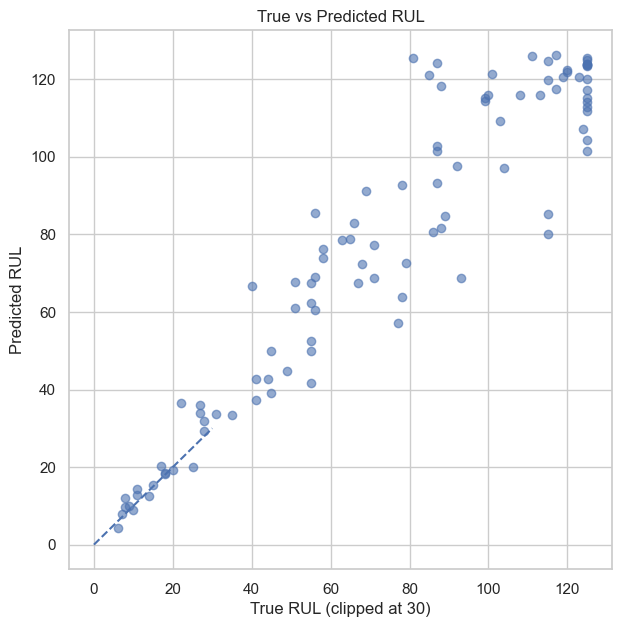

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_true_rul, y_pred_rul, alpha=0.6)
plt.plot([0, 30], [0, 30], linestyle="--")
plt.xlabel("True RUL (clipped at 125)")
plt.ylabel("Predicted RUL")
plt.title("True vs Predicted RUL")
plt.show()

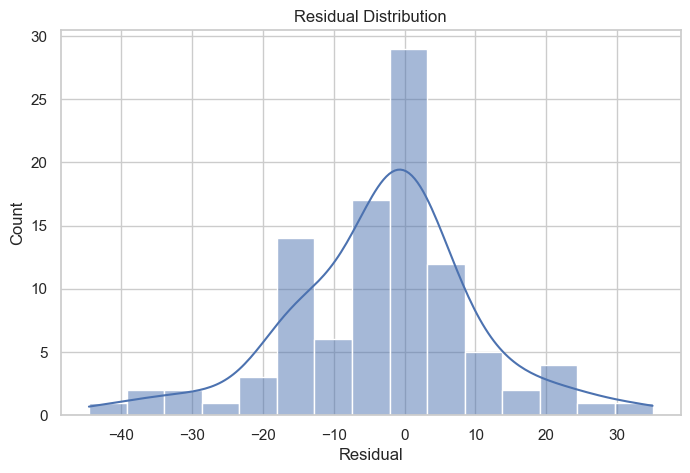

In [17]:
residuals = y_true_rul - y_pred_rul

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.show()

In [18]:
X_cls = test_df[classifier_features]
y_true_cls = test_df["label_30"]

In [19]:
y_prob = classifier_model.predict_proba(X_cls)[:, 1]
y_pred_cls = classifier_model.predict(X_cls)

test_df["failure_probability"] = y_prob

In [20]:
accuracy = accuracy_score(y_true_cls, y_pred_cls)
precision = precision_score(y_true_cls, y_pred_cls, zero_division=0)
recall = recall_score(y_true_cls, y_pred_cls, zero_division=0)
f1 = f1_score(y_true_cls, y_pred_cls, zero_division=0)
roc_auc = roc_auc_score(y_true_cls, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)

Accuracy: 0.23
Precision: 0.20618556701030927
Recall: 1.0
F1-score: 0.3418803418803419
ROC-AUC: 0.96625


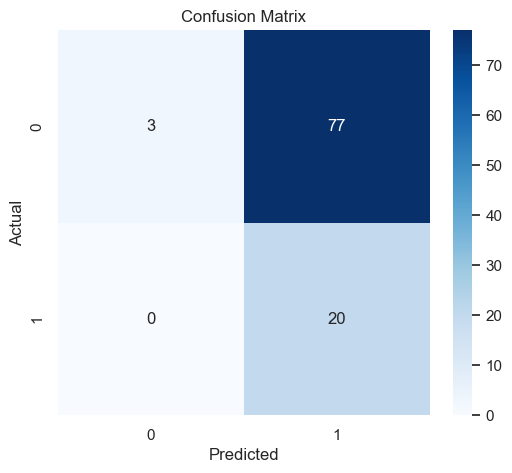

In [21]:
cm = confusion_matrix(y_true_cls, y_pred_cls)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

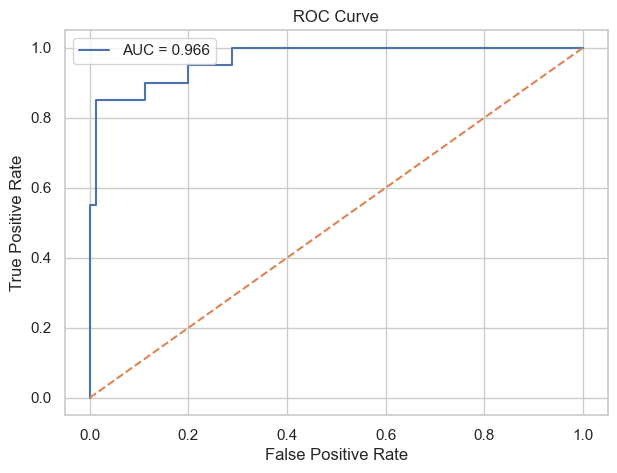

In [22]:
fpr, tpr, _ = roc_curve(y_true_cls, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

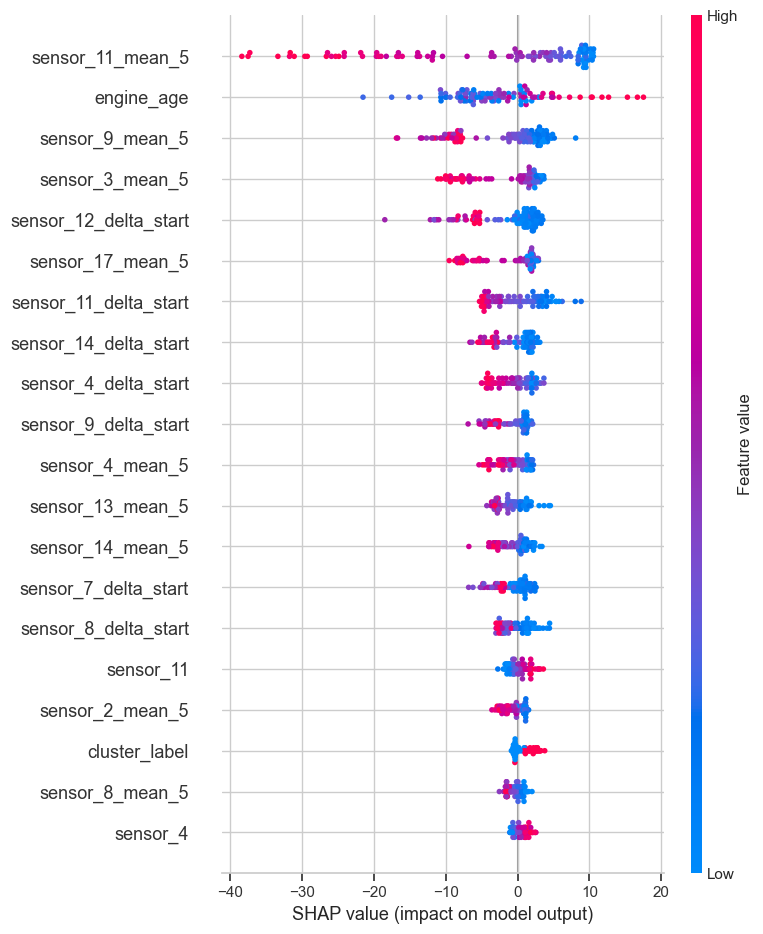

In [23]:
explainer_reg = shap.Explainer(rul_model)
shap_values_reg = explainer_reg(X_reg)

shap.summary_plot(shap_values_reg, X_reg)

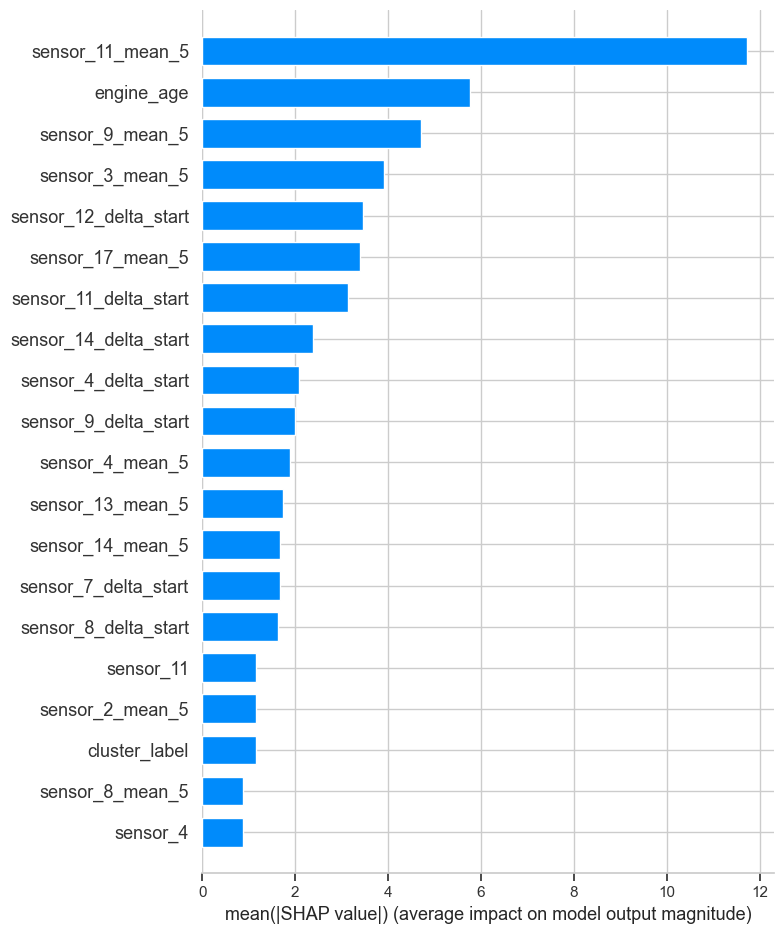

In [24]:
shap.summary_plot(shap_values_reg, X_reg, plot_type="bar")

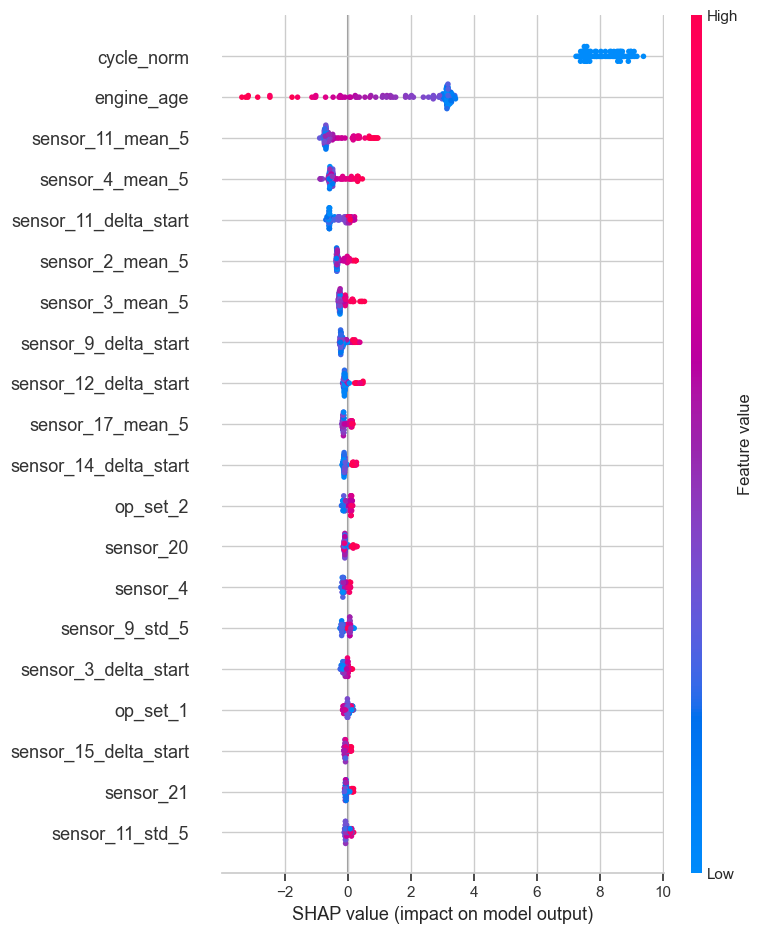

In [25]:
explainer_cls = shap.Explainer(classifier_model)
shap_values_cls = explainer_cls(X_cls)

shap.summary_plot(shap_values_cls, X_cls)

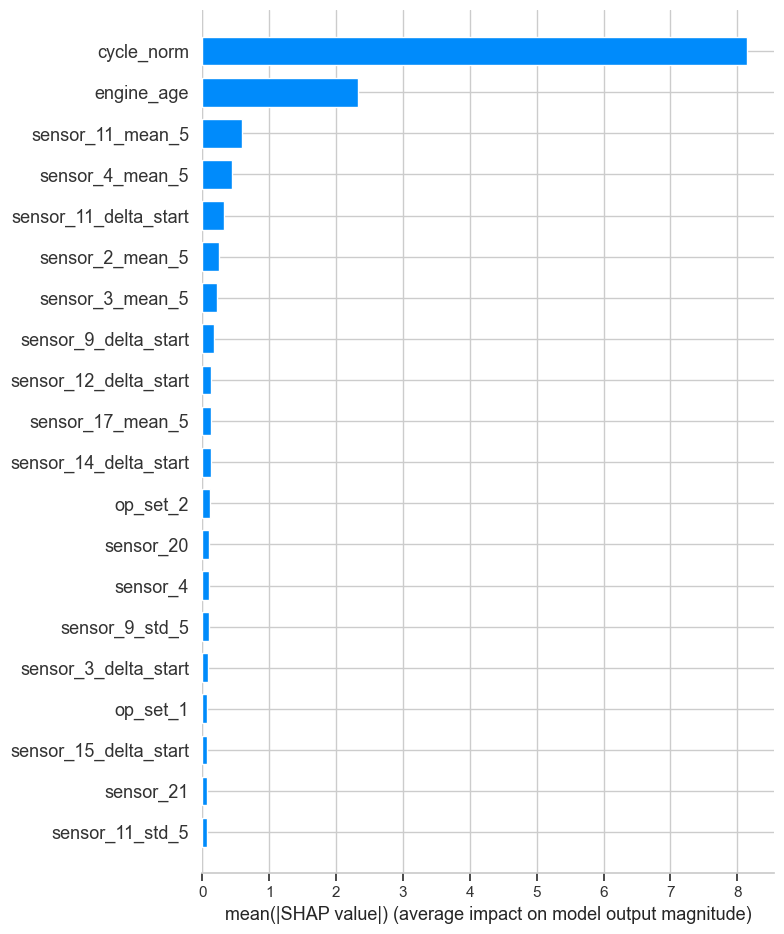

In [26]:
shap.summary_plot(shap_values_cls, X_cls, plot_type="bar")

In [27]:
test_df["normalized_cycle"] = test_df["cycle"] / test_df["cycle"].max()

cluster_weight_map = {
    0: 0.1,
    1: 0.3,
    2: 0.6
}

test_df["cluster_weight"] = test_df["cluster_label"].map(cluster_weight_map)

test_df["priority_score"] = (
    0.6 * test_df["failure_probability"] +
    0.3 * test_df["normalized_cycle"] +
    0.1 * test_df["cluster_weight"]
)

In [28]:
priority_table = test_df.sort_values(
    "priority_score",
    ascending=False
)[[
    "engine_id",
    "predicted_rul",
    "failure_probability",
    "cluster_label",
    "priority_score"
]]

display(priority_table.head(10))

,engine_id,predicted_rul,failure_probability,cluster_label,priority_score
23,24,9.995757,0.999633,0,0.909780
70,71,33.485596,0.997144,0,0.840076
93,94,9.046847,0.999904,0,0.820258
38,39,9.815359,0.999886,0,0.805721
98,99,11.998006,0.999902,0,0.792467
77,78,19.152239,0.999886,0,0.786142
91,92,12.593931,0.999862,0,0.777917
20,21,18.139963,0.999905,0,0.776048
63,64,31.860813,0.991421,0,0.776010
99,100,29.350798,0.998412,0,0.765047


In [29]:
OUTPUT_PATH = os.path.join(REPORT_DIR, "model_predictions_FD003.csv")
priority_table.to_csv(OUTPUT_PATH, index=False)

print("Saved evaluation output to:", OUTPUT_PATH)

Saved evaluation output to: ../reports\model_predictions_FD003.csv


In [30]:
summary = pd.DataFrame({
    "metric": [
        "RMSE",
        "MAE",
        "R2",
        "NASA_score",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ],
    "value": [
        rmse,
        mae,
        r2,
        nasa,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(summary)

,metric,value
0,RMSE,13.556985
1,MAE,9.619375
2,R2,0.880186
3,NASA_score,366.492023
4,Accuracy,0.230000
5,Precision,0.206186
6,Recall,1.000000
7,F1,0.341880
8,ROC_AUC,0.966250


In [31]:
DB_HOST = os.getenv("RDS_ENDPOINT")
DB_PORT = os.getenv("RDS_PORT")
DB_NAME = os.getenv("RDS_DB_NAME")
DB_USER = os.getenv("RDS_USERNAME")
DB_PASSWORD = os.getenv("RDS_PASSWORD")

DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

print("Connected to RDS successfully.")

Connected to RDS successfully.


In [32]:
from sqlalchemy import text

with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'public';
    """))
    
    for row in result:
        print(row[0])

model_audit_fd003
model_audit_fd003_classifier


In [33]:
from sqlalchemy import text

with engine.connect() as conn:

    print("Dropping old tables if they exist...")

    conn.execute(text("DROP TABLE IF EXISTS model_audit_fd003 CASCADE"))
    conn.execute(text("DROP TABLE IF EXISTS model_audit_fd003_classifier CASCADE"))

    print("Creating fresh tables...")

    conn.execute(text("""
    CREATE TABLE model_audit_fd003 (
        id SERIAL PRIMARY KEY,
        model_type VARCHAR(100),
        rmse FLOAT,
        r2_score FLOAT,
        nasa_safety_score FLOAT,
        feature_count INT,
        status VARCHAR(50),
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )
    """))

    conn.execute(text("""
    CREATE TABLE model_audit_fd003_classifier (
        id SERIAL PRIMARY KEY,
        model_type VARCHAR(100),
        accuracy FLOAT,
        precision_score FLOAT,
        recall_score FLOAT,
        f1_score FLOAT,
        roc_auc FLOAT,
        feature_count INT,
        status VARCHAR(50),
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )
    """))

    conn.commit()

print("Tables recreated successfully.")

Dropping old tables if they exist...
Creating fresh tables...
Tables recreated successfully.


In [34]:
regression_audit = {
    "model_type": "XGBRegressor_FD003",
    "rmse": float(rmse),
    "r2_score": float(r2),
    "nasa_safety_score": float(nasa),
    "feature_count": len(rul_features),
    "status": "Production_Ready"
}

regression_insert_query = """
INSERT INTO model_audit_fd003
(model_type, rmse, r2_score, nasa_safety_score, feature_count, status)
VALUES (:model_type, :rmse, :r2_score, :nasa_safety_score, :feature_count, :status)
"""

with engine.connect() as conn:
    conn.execute(text(regression_insert_query), regression_audit)
    conn.commit()

print("Regression performance logged to RDS.")

Regression performance logged to RDS.


In [35]:
classifier_audit = {
    "model_type": "XGBClassifier_FD003",
    "accuracy": float(accuracy),
    "precision_score": float(precision),
    "recall_score": float(recall),
    "f1_score": float(f1),
    "roc_auc": float(roc_auc),
    "feature_count": len(classifier_features),
    "status": "Production_Ready"
}

classifier_insert_query = """
INSERT INTO model_audit_fd003_classifier
(model_type, accuracy, precision_score, recall_score, f1_score, roc_auc, feature_count, status)
VALUES (:model_type, :accuracy, :precision_score, :recall_score, :f1_score, :roc_auc, :feature_count, :status)
"""

with engine.connect() as conn:
    conn.execute(text(classifier_insert_query), classifier_audit)
    conn.commit()

print("Classifier performance logged to RDS.")

Classifier performance logged to RDS.


In [36]:
summary.to_csv("../reports/performance_summary.csv", index=False)